# Dino Detector

This notebook recreates the original detector model but uses Dinov2 as the backbone.


*AI use disclaimer*

Mostly due to time constraints, Claude-sonnet 4.6 was used to help speed up the coding process.
Conceptualisation, raw code,, fine-tuning and improvement was done manually.

Uses include:

- For streamlining Detector dataset preparation section

- Debugging

- Generating code for plotting results

In [1]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm import tqdm
import random
import os
import copy

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import timm

from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_curve, roc_auc_score
)
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import label_binarize

from transformers import AutoModel
from torchvision import transforms
import torchvision.transforms as T
from sklearn.metrics import classification_report
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc as sklearn_auc
import torchvision.transforms.functional as F

plt.style.use('default')
sns.set_palette("husl")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch: {torch.__version__}, timm: {timm.__version__}, Device: {device}")

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# Paths
DATA_DIR = Path('/kaggle/input/datasets/archiesrikumar/bec-dataset/data')
DATA_FILES_DIR = DATA_DIR / 'data_files'
LABELS_FILE = DATA_DIR / 'data_info' / 'data_info' / 'data_roster.csv'

print(DATA_FILES_DIR.exists())
print(LABELS_FILE.exists())
labels_df = pd.read_csv(LABELS_FILE, index_col=0)


# Data Loading
def load_bec_dataset(data_dir, labels_df, max_samples=None, shuffle_seed=42):
    class_dirs = sorted(
        [d for d in data_dir.glob('class-*') if d.is_dir()],
        key=lambda p: int(p.name.split('-')[-1])
                       if p.name.split('-')[-1].isdigit() else 0
    )
    all_files = []
    for cd in class_dirs:
        all_files.extend(sorted(cd.glob('*.npy')))

    if shuffle_seed is not None:
        random.seed(shuffle_seed)
        random.shuffle(all_files)
    if max_samples:
        all_files = all_files[:max_samples]

    images, labels_list, positions_list = [], [], []
    for fp in tqdm(all_files, desc="Loading"):
        try:
            d = np.load(fp, allow_pickle=True).item()
            img = d['masked_data'].reshape(132, 164, 1)
            rel = '/data/' + '/'.join(fp.parts[-3:])
            if rel in labels_df.index:
                row = labels_df.loc[rel]
                label = int(row['label_v3'])
                pos_str = row['excitation_position']
                pos = []
                if not pd.isna(pos_str) and pos_str != '':
                    try:
                        pos = eval(pos_str) if isinstance(pos_str, str) else []
                        if not isinstance(pos, list):
                            pos = [pos] if pos else []
                    except:
                        pos = []
                images.append(img)
                labels_list.append(label)
                positions_list.append(pos)
        except Exception as e:
            print(f"Error: {fp}: {e}")

    images = np.array(images, dtype=np.float32)
    labels_arr = np.array(labels_list, dtype=np.int32)
    print(f"Loaded {len(images)} images {images.shape}")
    return images, labels_arr, positions_list


images, labels, positions = load_bec_dataset(
    DATA_FILES_DIR, labels_df, max_samples=None
)

valid = labels < 8
images_f = images[valid]
labels_f = labels[valid].copy()
positions_f = [positions[i] for i in range(len(positions)) if valid[i]]

labels_f[labels_f >= 2] = 2
print(f"Filtered: {len(images_f)}, distribution: {np.bincount(labels_f)}")

X_train, X_test, y_train, y_test, pos_train, pos_test = train_test_split(
    images_f, labels_f, positions_f,
    test_size=0.2, random_state=42, stratify=labels_f
)
print(f"Train: {len(X_train)}, Test: {len(X_test)}")
print(f"Train dist: {np.bincount(y_train)}, Test dist: {np.bincount(y_test)}")

PyTorch: 2.10.0+cu128, timm: 1.0.25, Device: cuda
True
True


Loading: 100%|██████████| 16478/16478 [02:20<00:00, 117.46it/s]


Loaded 16478 images (16478, 132, 164, 1)
Filtered: 5378, distribution: [1130 3212 1036]
Train: 4302, Test: 1076
Train dist: [ 904 2569  829], Test dist: [226 643 207]


In [2]:
#  Detector Data Preparation
IMAGE_WIDTH = 164
NUM_BINS = 40

"""
These functions prepare and interpret position-based labels for a detector model."""

#ensures all position values are floats. 

def normalize_position_list(pos_list):
    if isinstance(pos_list, list):
        return [float(p) for p in pos_list]
    return []


#converts lists of object positions into a structured label tensor of shape (N, 1, 40, 2), 
#each bin stores whether an object is present and its relative offset within that bin. 

def positions_to_40_labels(position_batches, image_width=IMAGE_WIDTH):
    """Convert position lists to (N, 1, 40, 2) detector labels."""
    n_bins = 40
    labels_40 = np.zeros((len(position_batches), 1, n_bins, 2),
                         dtype=np.float32)
    for i, pos_list in enumerate(position_batches):
        for pos in normalize_position_list(pos_list):
            if 0 < pos < image_width:
                bin_idx = min(int(pos // 4), n_bins - 1)
                labels_40[i, 0, bin_idx, 0] = 1.0      # presence
                labels_40[i, 0, bin_idx, 1] = (pos % 4) / 4.0  # sub-bin offset
    return labels_40


#read model outputs,selects bins with confidence above a threshold, reconstructs continuous positions,
# and merges nearby detections to avoid duplicates. 
def labels40_to_positions(label_array, prob_threshold=0.5,
                          merge_threshold=4.0):
    """Convert (N, 1, 40, 2) detector output back to position lists."""
    batch_positions = []
    for sample in label_array:
        positions = []
        for bin_idx in range(sample.shape[1]):
            if sample[0, bin_idx, 0] > prob_threshold:
                positions.append(
                    float(bin_idx * 4 + sample[0, bin_idx, 1] * 4)
                )
        # Merge nearby detections
        merged = []
        for pos in sorted(positions):
            if merged and (pos - merged[-1]) < merge_threshold:
                merged[-1] = 0.5 * (merged[-1] + pos)
            else:
                merged.append(pos)
        batch_positions.append(merged)
    return batch_positions


# Filter to class 0 and 1 only (need position labels)
train_det_mask = y_train < 2
test_det_mask  = y_test  < 2

X_train_det = X_train[train_det_mask]
X_test_det  = X_test[test_det_mask]
y_train_det = y_train[train_det_mask]
y_test_det  = y_test[test_det_mask]
pos_train_det = [pos_train[i]
                 for i in range(len(pos_train)) if train_det_mask[i]]
pos_test_det  = [pos_test[i]
                 for i in range(len(pos_test))  if test_det_mask[i]]

# Convert positions to 40-bin labels
y_train_det_40 = positions_to_40_labels(pos_train_det)
y_test_det_40  = positions_to_40_labels(pos_test_det)

print(f"Detector train: {len(X_train_det)} samples")
print(f"Detector test:  {len(X_test_det)} samples")
print(f"  Class 0 (no soliton): "
      f"{(y_train_det == 0).sum()} train, {(y_test_det == 0).sum()} test")
print(f"  Class 1 (soliton):    "
      f"{(y_train_det == 1).sum()} train, {(y_test_det == 1).sum()} test")
print(f"  Train positives (has position): "
      f"{sum(len(p) > 0 for p in pos_train_det)}")
print(f"  Label tensor shape: {y_train_det_40.shape}")

Detector train: 3473 samples
Detector test:  869 samples
  Class 0 (no soliton): 904 train, 226 test
  Class 1 (soliton):    2569 train, 643 test
  Train positives (has position): 2569
  Label tensor shape: (3473, 1, 40, 2)


In [3]:
# Detector Dataset
class BECDetectorDataset(Dataset):
    def __init__(self, images, labels, transform=None):  # FIX 6
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = np.squeeze(self.images[idx]).astype(np.float32)
        if img.max() > 1.0:
            img /= 255.0

        img_tensor = torch.from_numpy(np.stack([img, img, img], axis=0))
        img_tensor = F.resize(img_tensor, (224, 224), antialias=True)

        mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
        img_tensor = (img_tensor - mean) / std

        label = torch.tensor(self.labels[idx], dtype=torch.float32)
        return img_tensor, label

In [4]:
# Detector Model (DINOv2 backbone + detection head)
def create_Dinov2_detector(freeze_backbone=True, num_bins=40):
    """Create DINOv2 detector."""
    backbone = AutoModel.from_pretrained('facebook/dinov2-small')
    feat_dim = backbone.config.hidden_size

    if freeze_backbone:
        for param in backbone.parameters():
            param.requires_grad = False

    print(f"Feature dim: {feat_dim}")
    print(f"Num bins: {num_bins}")

    detector_head = nn.Sequential(
        nn.Linear(feat_dim, 256),
        nn.GELU(),
        nn.Linear(256, 256),  #added an extra layer - it seems to have improved
        nn.GELU(),
        nn.Dropout(0.1),
        nn.Linear(256, 256),
        nn.GELU(),
        nn.Dropout(0.2), #was 0.1 
        nn.Linear(256, num_bins * 2),   # <-- was num_bins
        nn.Sigmoid(),
    )

    class DINOv2Detector(nn.Module):
        def __init__(self, backbone, head):   
            super().__init__()
            self.backbone = backbone
            self.head = head

        def forward(self, x):
            features = self.backbone(x).pooler_output
            return self.head(features)

    model = DINOv2Detector(backbone, detector_head)
    model.to(device)

    print(f"Model created on {device}. Backbone frozen: {freeze_backbone}")
    return model


def unfreeze_detector(model, backbone_lr=1e-5, head_lr=1e-4):
    """Unfreeze detector with differential LRs."""
    for p in model.parameters():
        p.requires_grad = True

    backbone_params = []
    head_params = []
    for name, p in model.named_parameters():
        if 'head' in name and 'backbone' not in name:
            head_params.append(p)
        else:
            backbone_params.append(p)

    trainable = sum(p.numel() for p in model.parameters()
                    if p.requires_grad)
    print(f"Unfrozen: {trainable:,} trainable parameters")
    return [
        {'params': backbone_params, 'lr': backbone_lr},
        {'params': head_params,     'lr': head_lr},
    ]

In [5]:
# Metz Loss + Detector Training Functions

def metz_loss(y_pred, y_true):
    """
    Custom loss for object detector.
    Channel 0: Weighted BCE for presence detection (10× positive weight)
    Channel 1: MSE for position regression (only where present)
    """
    y_pred = y_pred.view(y_pred.size(0), 40, 2)
    y_true = y_true.view(y_true.size(0), 40, 2)    # safe for any batch size

    presence_true = y_true[..., 0]
    presence_pred = y_pred[..., 0].clamp(1e-7, 1 - 1e-7)
    bce = (-10 * presence_true * torch.log(presence_pred)
           - (1 - presence_true) * torch.log(1 - presence_pred))

    position_true = y_true[..., 1]
    position_pred = y_pred[..., 1]
    mse = 10 * presence_true * (position_true - position_pred) ** 2

    return (bce + mse).sum()


def train_epoch_det(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, total = 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        preds = model(imgs)
        loss = criterion(preds, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()
        total += imgs.size(0)
    return total_loss / total


@torch.no_grad()
def eval_det(model, loader, criterion, device):
    model.eval()
    total_loss, total = 0, 0
    all_preds = []
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        preds = model(imgs)
        loss = criterion(preds, labels)
        total_loss += loss.item()
        total += imgs.size(0)
        all_preds.append(preds.cpu().numpy())
    return total_loss / total, np.concatenate(all_preds, axis=0)


def two_phase_train_det(model, train_loader, val_loader, device,
                        phase1_epochs=30, phase2_epochs=50,
                        phase1_lr=1e-3,
                        phase2_backbone_lr=1e-5, phase2_head_lr=1e-4):
    """Two-phase detector training with Metz loss."""
    history = {'phase': [], 'epoch': [], 'train_loss': [], 'val_loss': []}
    best_val_loss = float('inf')
    best_state = None
    PATIENCE = 10

    # Phase 1: head only
    print("Phase 1: Detector head only")
    opt = optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=phase1_lr, weight_decay=1e-4
    )
    sched = optim.lr_scheduler.CosineAnnealingLR(
        opt, T_max=phase1_epochs, eta_min=phase1_lr * 0.01
    )

    for epoch in range(phase1_epochs):
        tl = train_epoch_det(model, train_loader, metz_loss, opt, device)
        vl, _ = eval_det(model, val_loader, metz_loss, device)
        sched.step()

        history['phase'].append(1)
        history['epoch'].append(epoch)
        history['train_loss'].append(tl)
        history['val_loss'].append(vl)

        if vl < best_val_loss:
            best_val_loss = vl
            best_state = copy.deepcopy(model.state_dict())

        if (epoch + 1) % 5 == 0:
            print(f"  {epoch+1}/{phase1_epochs} | "
                  f"train_loss={tl:.4f} val_loss={vl:.4f} | "
                  f"lr={opt.param_groups[0]['lr']:.2e}")

    # Phase 2: full model
    print(f"\nPhase 2: Full fine-tuning")
    model.load_state_dict(best_state)
    param_groups = unfreeze_detector(model, phase2_backbone_lr, phase2_head_lr)
    opt = optim.AdamW(param_groups, weight_decay=1e-4)
    sched = optim.lr_scheduler.CosineAnnealingLR(
        opt, T_max=phase2_epochs, eta_min=phase2_backbone_lr * 0.01
    )
    patience_counter = 0

    for epoch in range(phase2_epochs):
        tl = train_epoch_det(model, train_loader, metz_loss, opt, device)
        vl, _ = eval_det(model, val_loader, metz_loss, device)
        sched.step()

        history['phase'].append(2)
        history['epoch'].append(phase1_epochs + epoch)
        history['train_loss'].append(tl)
        history['val_loss'].append(vl)

        if vl < best_val_loss:
            best_val_loss = vl
            best_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= PATIENCE:
            print(f"  Early stopping at epoch {epoch+1}")
            break

        if (epoch + 1) % 5 == 0:
            print(f"  {epoch+1}/{phase2_epochs} | "
                  f"train_loss={tl:.4f} val_loss={vl:.4f} | "
                  f"backbone_lr={opt.param_groups[0]['lr']:.2e}")

    model.load_state_dict(best_state)
    print(f"\nBest val loss: {best_val_loss:.4f}")
    return history

In [6]:
#Train Detector
print("DETECTOR TRAINING: DINOv2-small + Metz Loss")

detector = create_Dinov2_detector(
    freeze_backbone=True, num_bins=NUM_BINS
).to(device)

train_det_ds = BECDetectorDataset(X_train_det, y_train_det_40)
test_det_ds  = BECDetectorDataset(X_test_det,  y_test_det_40)

train_det_loader = DataLoader(train_det_ds, batch_size=16,
                              shuffle=True, num_workers=2)
test_det_loader  = DataLoader(test_det_ds,  batch_size=16,
                              shuffle=False, num_workers=2)

print(f"Train: {len(train_det_ds)} samples")
print(f"Test:  {len(test_det_ds)} samples")

det_history = two_phase_train_det(
    detector, train_det_loader, test_det_loader, device,
    phase1_epochs=20,
    phase2_epochs=50,
    phase1_lr=1e-3,
    phase2_backbone_lr=1e-6,
    phase2_head_lr=1e-4,
)
torch.save(detector.state_dict(), 'dinov2_detector_metz.pth')
print("Saved detector model")

DETECTOR TRAINING: DINOv2-small + Metz Loss


config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/88.2M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

Feature dim: 384
Num bins: 40
Model created on cuda. Backbone frozen: True
Train: 3473 samples
Test:  869 samples
Phase 1: Detector head only
  5/20 | train_loss=10.1751 val_loss=10.0997 | lr=8.55e-04
  10/20 | train_loss=8.3574 val_loss=8.3490 | lr=5.05e-04
  15/20 | train_loss=6.3572 val_loss=6.8036 | lr=1.55e-04
  20/20 | train_loss=5.7074 val_loss=6.3163 | lr=1.00e-05

Phase 2: Full fine-tuning
Unfrozen: 22,307,280 trainable parameters
  5/50 | train_loss=3.5878 val_loss=2.8742 | backbone_lr=9.76e-07
  10/50 | train_loss=2.3941 val_loss=2.9953 | backbone_lr=9.05e-07
  15/50 | train_loss=1.8401 val_loss=2.3279 | backbone_lr=7.96e-07
  20/50 | train_loss=1.4796 val_loss=1.9902 | backbone_lr=6.58e-07
  25/50 | train_loss=0.9714 val_loss=2.3822 | backbone_lr=5.05e-07
  30/50 | train_loss=0.7260 val_loss=2.1403 | backbone_lr=3.52e-07
  35/50 | train_loss=0.5753 val_loss=2.0937 | backbone_lr=2.14e-07
  Early stopping at epoch 36

Best val loss: 1.8655
Saved detector model


In [7]:
 
#  Detector Evaluation
print("DETECTOR EVALUATION")

_, det_preds = eval_det(detector, test_det_loader, metz_loss, device)

det_preds_reshaped = det_preds.reshape(-1, 1, NUM_BINS, 2)
predicted_positions = labels40_to_positions(det_preds_reshaped)
true_positions = [normalize_position_list(p) for p in pos_test_det]

# Presence metrics
presence_true = np.array([len(p) > 0 for p in true_positions], dtype=int)
presence_pred = np.array([len(p) > 0 for p in predicted_positions], dtype=int)

tp = int(((presence_true == 1) & (presence_pred == 1)).sum())
fp = int(((presence_true == 0) & (presence_pred == 1)).sum())
fn = int(((presence_true == 1) & (presence_pred == 0)).sum())
tn = int(((presence_true == 0) & (presence_pred == 0)).sum())

prec = tp / max(tp + fp, 1)
rec  = tp / max(tp + fn, 1)
f1   = 2 * prec * rec / max(prec + rec, 1e-8)

print(f"Presence Detection:")
print(f"  TP={tp}, FP={fp}, FN={fn}, TN={tn}")
print(f"  Precision: {prec:.4f}")
print(f"  Recall:    {rec:.4f}")
print(f"  F1:        {f1:.4f}")

# Localization error (distance between predicted and true positions)
loc_errors = []
for true_pos, pred_pos in zip(true_positions, predicted_positions):
    if true_pos and pred_pos:
        loc_errors.append(abs(pred_pos[0] - true_pos[0]))

if loc_errors:
    print(f"\nLocalization Error:")
    print(f"  Mean:   {np.mean(loc_errors):.2f} pixels")
    print(f"  Median: {np.median(loc_errors):.2f} pixels")
    print(f"  Std:    {np.std(loc_errors):.2f} pixels")
    print(f"  Max:    {np.max(loc_errors):.2f} pixels")
else:
    print("\nNo matched detections for localization error")

DETECTOR EVALUATION
Presence Detection:
  TP=643, FP=7, FN=0, TN=219
  Precision: 0.9892
  Recall:    1.0000
  F1:        0.9946

Localization Error:
  Mean:   0.60 pixels
  Median: 0.32 pixels
  Std:    2.67 pixels
  Max:    62.85 pixels


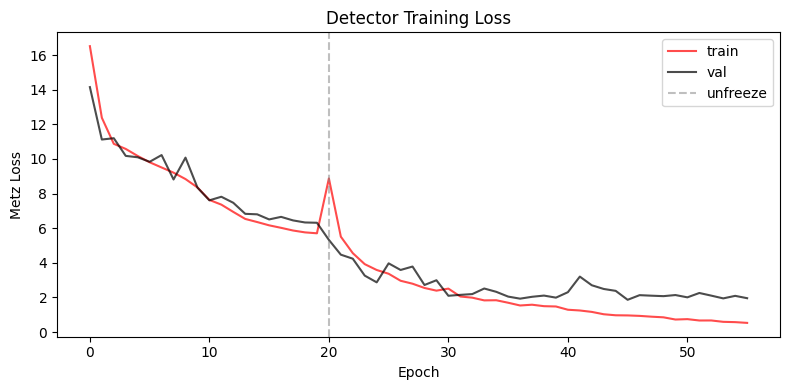

In [8]:
#  Detector Visualization

fig, ax = plt.subplots(1, 1, figsize=(8, 4))
phase1_end = sum(1 for p in det_history['phase'] if p == 1)
ax.plot(det_history['train_loss'], color= "r", label='train', alpha=0.7)
ax.plot(det_history['val_loss'], color="black",  label='val',   alpha=0.7)
ax.axvline(x=phase1_end, color='gray', ls='--', alpha=0.5,
           label='unfreeze')
ax.set_xlabel('Epoch')
ax.set_ylabel('Metz Loss')
ax.set_title('Detector Training Loss')
ax.legend()
plt.tight_layout()
plt.savefig("Detloss.png")
plt.show()

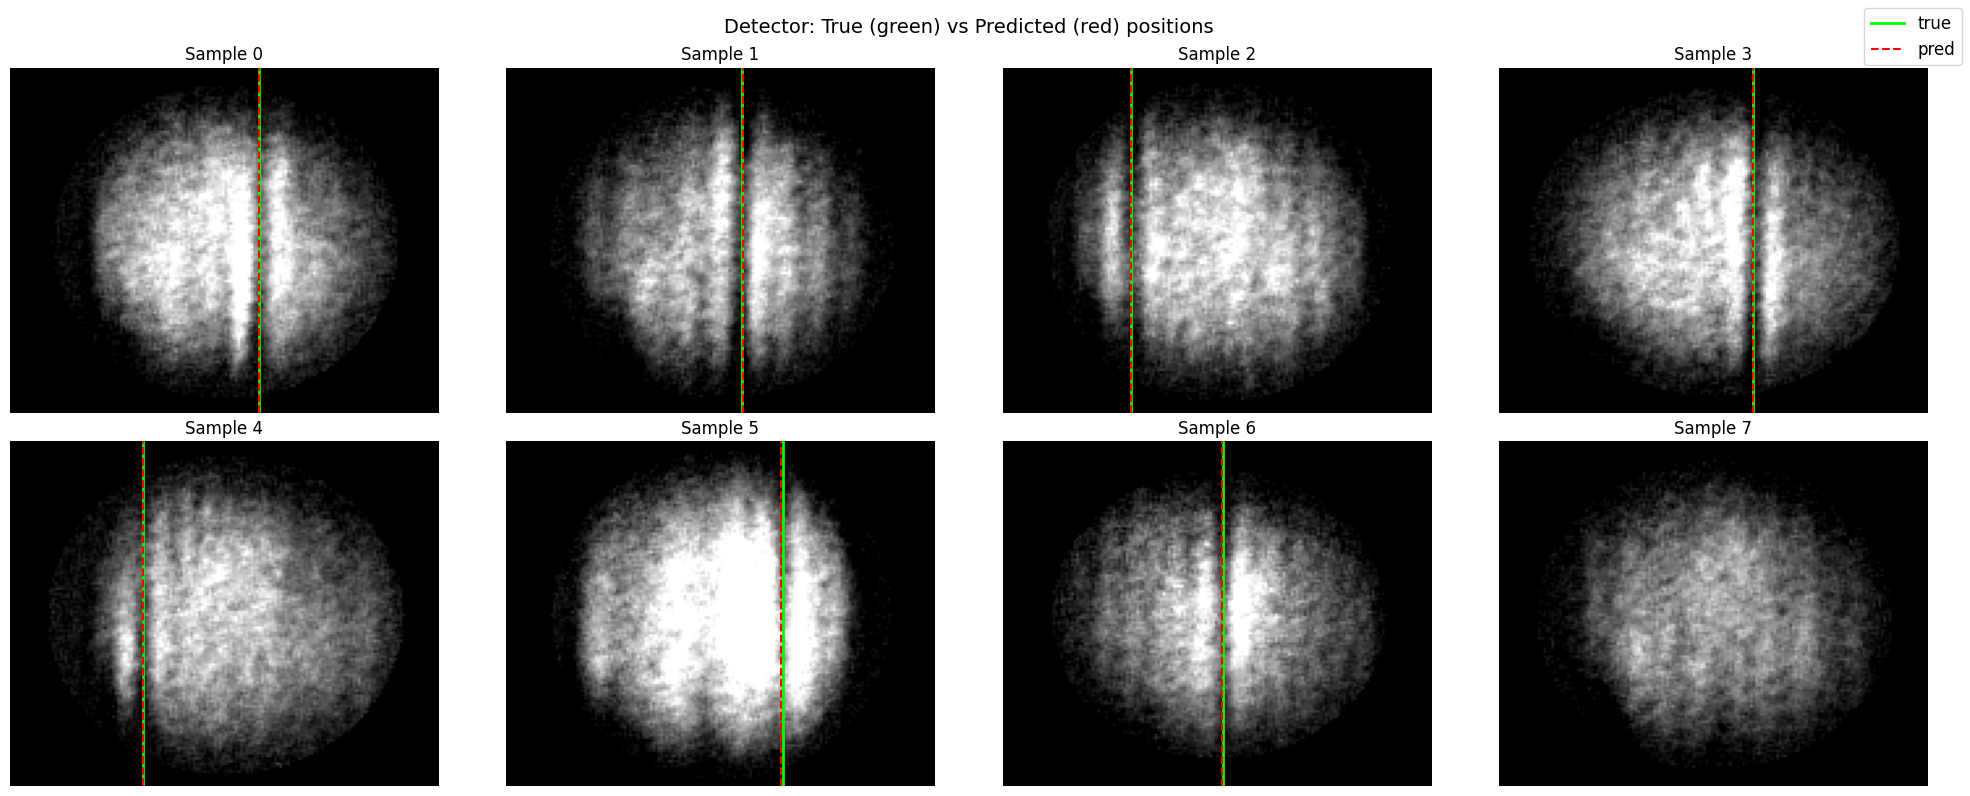

In [9]:
# Sample predictions
n_show = min(8, len(X_test_det))
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()

for i in range(n_show):
    axes[i].imshow(X_test_det[i].squeeze(), cmap='gray', vmin=0, vmax=1)
    for tp_ in true_positions[i]:
        axes[i].axvline(tp_, color='lime', lw=2,
                        label='true' if i == 0 else '')
    for pp in predicted_positions[i]:
        axes[i].axvline(pp, color='red', lw=1.5, ls='--',
                        label='pred' if i == 0 else '')
    axes[i].set_title(f"Sample {i}")
    axes[i].axis('off')

handles, label_texts = axes[0].get_legend_handles_labels()
if handles:
    fig.legend(handles, label_texts, loc='upper right', fontsize=12)
plt.suptitle('Detector: True (green) vs Predicted (red) positions',
             fontsize=14)
plt.tight_layout()
plt.savefig("pred images.png")
plt.show()

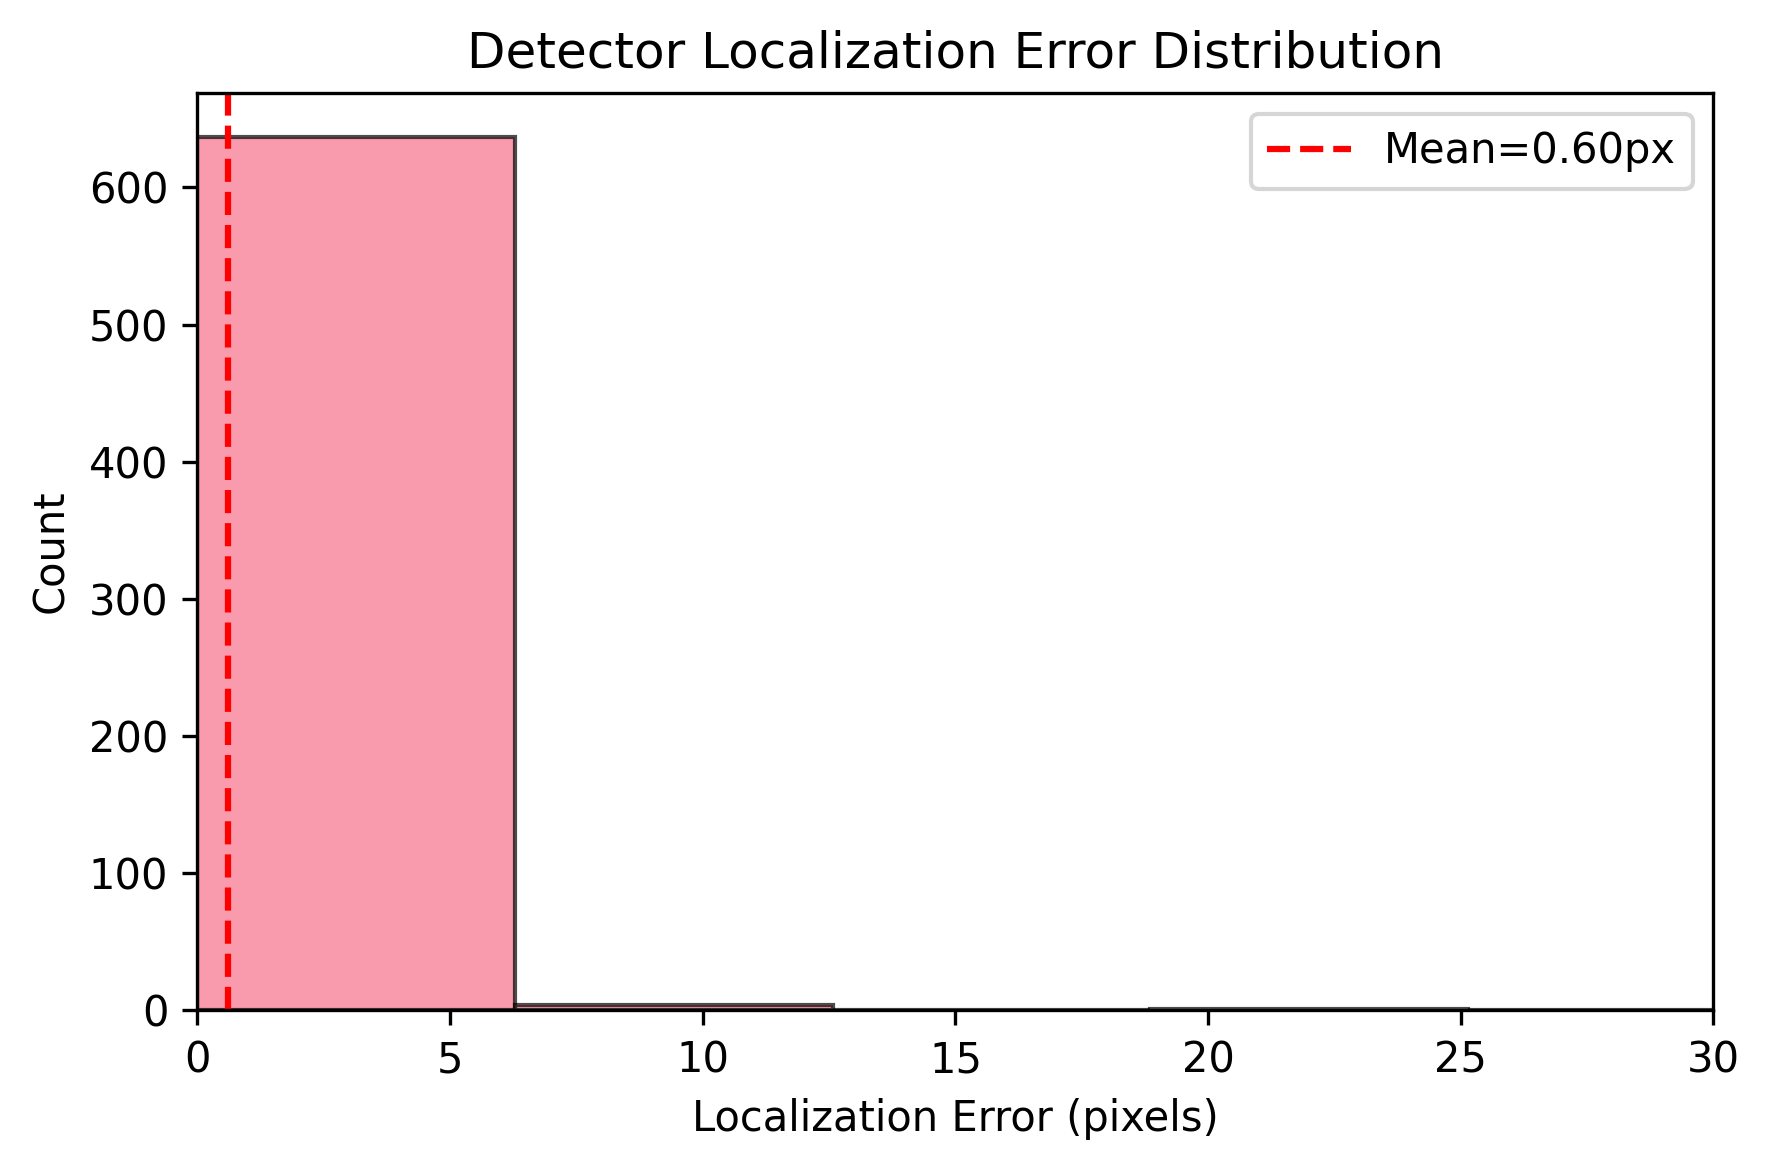

In [15]:
# Localization error histogram
if loc_errors:
    plt.figure(figsize=(6, 4), dpi=300)
    plt.hist(loc_errors, bins=10, edgecolor='black', alpha=0.7)
    plt.axvline(np.mean(loc_errors), color='red', ls='--',
                label=f'Mean={np.mean(loc_errors):.2f}px')
    plt.xlabel('Localization Error (pixels)')
    plt.xlim(0,30)
    plt.ylabel('Count')
    plt.title('Detector Localization Error Distribution')
    plt.legend()
    plt.tight_layout()
    plt.savefig("Detector loc error.png")
    plt.show()